# Combined Notebook: Severity Level Classification for Cybersecurity Attacks Dataset

This Kaggle-ready notebook uses **classification** with `Severity Level` as the target variable.

Input path used first:

`/kaggle/input/datasets/teamincribo/cyber-security-attacks`

The notebook also falls back to recursive search under `/kaggle/input`.

All tables are saved as CSV files and all figures are saved as PDF files.

Leakage-aware default: `Anomaly Scores`, `Action Taken`, and `Attack Type` are removed from the feature set.

## Common setup and data preparation

In [1]:
import os
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import BernoulliNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
TARGET_COLUMN = "Severity Level"
PREFERRED_INPUT_DIR = Path("/kaggle/input/datasets/teamincribo/cyber-security-attacks")
OUTPUT_ROOT = Path("/kaggle/working/severity_classification_outputs")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_ROOT)

def find_dataset_file(preferred_dir=PREFERRED_INPUT_DIR):
    supported_ext = [".csv", ".xlsx", ".xls"]
    roots = []
    if Path(preferred_dir).exists():
        roots.append(Path(preferred_dir))
    if Path("/kaggle/input").exists():
        roots.append(Path("/kaggle/input"))
    for r in [Path("."), Path("/mnt/data")]:
        if r.exists():
            roots.append(r)

    candidates = []
    for root in roots:
        for ext in supported_ext:
            candidates.extend(root.rglob(f"*{ext}"))

    candidates = [c for c in candidates if not any(x in c.name.lower() for x in ["sample_submission", "submission"])]

    if not candidates:
        raise FileNotFoundError("No CSV/XLS/XLSX dataset file found.")

    keywords = ["cyber", "security", "attack"]
    candidates = sorted(
        candidates,
        key=lambda p: (str(p).startswith(str(PREFERRED_INPUT_DIR)), sum(k in p.name.lower() for k in keywords)),
        reverse=True
    )
    print("Selected dataset file:", candidates[0])
    return candidates[0]

def load_raw_dataset():
    path = find_dataset_file()
    if path.suffix.lower() == ".csv":
        data = pd.read_csv(path)
    else:
        data = pd.read_excel(path)
    print("Dataset shape:", data.shape)
    display(data.head())
    return data

def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True, min_frequency=20)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

def prepare_classification_features(
    data,
    include_attack_type=False,
    include_anomaly_scores=False,
    create_missing_indicators=True,
    use_timestamp_features=True,
    use_ip_prefix_features=True,
    drop_high_cardinality_text=True
):
    if TARGET_COLUMN not in data.columns:
        raise KeyError(f"Target column '{TARGET_COLUMN}' not found.")

    df = data.copy()
    y = df[TARGET_COLUMN].astype(str)
    X = df.drop(columns=[TARGET_COLUMN])

    leakage_cols = ["Action Taken"]
    if not include_anomaly_scores:
        leakage_cols.append("Anomaly Scores")
    if not include_attack_type:
        leakage_cols.append("Attack Type")
    X = X.drop(columns=leakage_cols, errors="ignore")

    if use_timestamp_features and "Timestamp" in X.columns:
        ts = pd.to_datetime(X["Timestamp"], errors="coerce")
        X["hour"] = ts.dt.hour
        X["dayofweek"] = ts.dt.dayofweek
        X["month"] = ts.dt.month
        X = X.drop(columns=["Timestamp"], errors="ignore")

    if use_ip_prefix_features:
        ip_map = {
            "Source IP Address": "source_ip_prefix",
            "Destination IP Address": "destination_ip_prefix",
            "Proxy Information": "proxy_ip_prefix"
        }
        for old, new in ip_map.items():
            if old in X.columns:
                X[new] = X[old].astype(str).str.split(".").str[0].replace({"nan": np.nan})
                X = X.drop(columns=[old], errors="ignore")

    if create_missing_indicators:
        for col in ["Alerts/Warnings", "IDS/IPS Alerts", "Malware Indicators", "Firewall Logs", "Proxy Information"]:
            if col in X.columns:
                X[col + "_missing"] = X[col].isna().astype(int)

    if drop_high_cardinality_text:
        X = X.drop(columns=["Payload Data", "User Information", "Device Information", "Geo-location Data"], errors="ignore")

    return X, y

def build_preprocessor(X, scale_numeric=True):
    num_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32", "bool"]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=["int64", "float64", "int32", "float32", "bool"]).columns.tolist()

    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler(with_mean=False)))

    preprocessor = ColumnTransformer([
        ("num", Pipeline(num_steps), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("encoder", make_onehot_encoder())
        ]), cat_cols)
    ])

    return preprocessor, num_cols, cat_cols

def split_data(X, y, test_size=0.20):
    return train_test_split(X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y)

def evaluate_predictions(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision Macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall Macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 Macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 Weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

def fit_evaluate_model(name, estimator, X_train, X_test, y_train, y_test, preprocessor):
    pipe = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    start = time.time()
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    elapsed = time.time() - start
    metrics = evaluate_predictions(y_test, pred)
    metrics["Model"] = name
    metrics["Training Time Seconds"] = elapsed
    return metrics, pred, pipe

def get_candidate_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=500, class_weight="balanced", solver="saga", n_jobs=-1, random_state=RANDOM_STATE),
        "Decision Tree Classifier": DecisionTreeClassifier(max_depth=14, min_samples_leaf=5, class_weight="balanced", random_state=RANDOM_STATE),
        "Random Forest Classifier": RandomForestClassifier(n_estimators=20, max_depth=10, min_samples_leaf=5, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1),
        "Extra Trees Classifier": ExtraTreesClassifier(n_estimators=20, max_depth=10, min_samples_leaf=5, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
        "SGD Linear Classifier": SGDClassifier(loss="log_loss", penalty="l2", alpha=0.0005, class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1),
        "Bernoulli Naive Bayes": BernoulliNB()
    }

def save_table(table, filename, output_dir=OUTPUT_ROOT):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    path = output_dir / filename
    table.to_csv(path, index=False)
    print("Saved table:", path)
    return path

def save_figure(fig, filename, output_dir=OUTPUT_ROOT):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    path = output_dir / filename
    fig.savefig(path, format="pdf", bbox_inches="tight")
    plt.show()
    print("Saved figure:", path)
    return path

def style_axes(ax):
    ax.grid(True, alpha=0.30, linestyle="--")
    ax.set_axisbelow(True)

df = load_raw_dataset()

target_distribution = df[TARGET_COLUMN].value_counts(dropna=False).reset_index()
target_distribution.columns = [TARGET_COLUMN, "Count"]
display(target_distribution)

X, y = prepare_classification_features(df)
preprocessor, numeric_features, categorical_features = build_preprocessor(X, scale_numeric=True)
X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.20)

print("Prepared feature matrix shape:", X.shape)
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Class labels:", sorted(y.unique()))

Output directory: /kaggle/working/severity_classification_outputs
Selected dataset file: /kaggle/input/datasets/teamincribo/cyber-security-attacks/cybersecurity_attacks.csv
Dataset shape: (40000, 25)


,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


,Severity Level,Count
0,Medium,13435
1,High,13382
2,Low,13183


Prepared feature matrix shape: (40000, 23)
Numeric features: 10
Categorical features: 13
Class labels: ['High', 'Low', 'Medium']


## RQ1: Baseline classification performance

Training Most Frequent Baseline...
Training Stratified Random Baseline...
Training Logistic Regression...
Training Decision Tree Classifier...
Training SGD Linear Classifier...


,Model,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted,Training Time Seconds
1,Stratified Random Baseline,0.334125,0.334146,0.334151,0.334146,0.334092,0.334089,0.504075
2,Logistic Regression,0.330125,0.330088,0.330063,0.330088,0.330025,0.330074,1.121403
4,SGD Linear Classifier,0.331125,0.330838,0.336340,0.330838,0.277536,0.277479,0.795268
3,Decision Tree Classifier,0.334375,0.332385,0.333857,0.332385,0.250588,0.251610,0.905944
0,Most Frequent Baseline,0.335875,0.333333,0.111958,0.333333,0.167618,0.168896,0.561422


Saved table: /kaggle/working/severity_classification_outputs/rq1_baseline/table_rq1_baseline_classification.csv


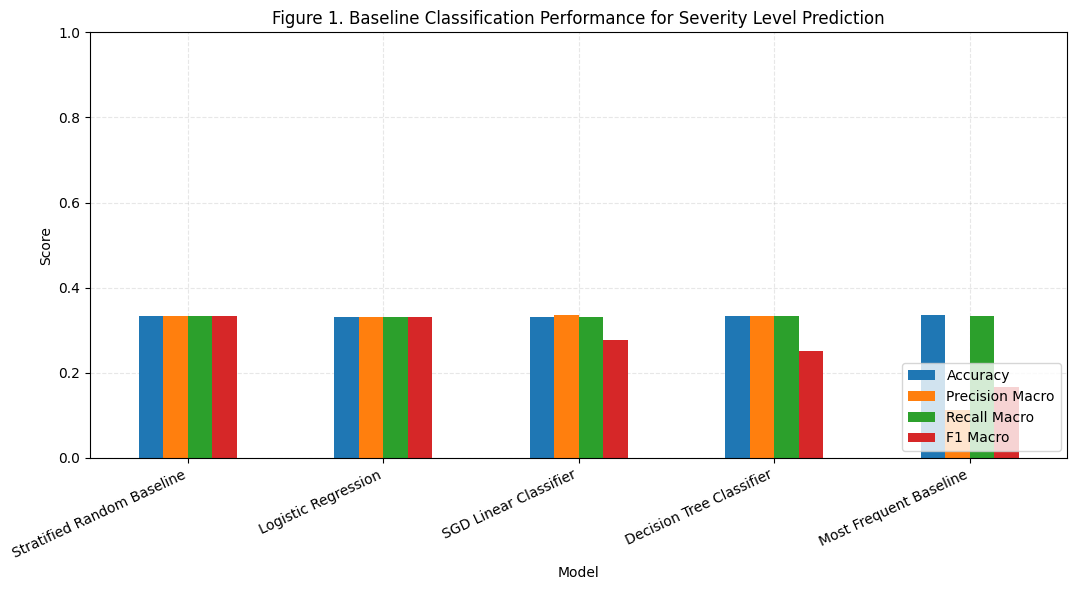

Saved figure: /kaggle/working/severity_classification_outputs/rq1_baseline/figure_rq1_baseline_classification.pdf


,Predicted High,Predicted Low,Predicted Medium
Actual High,867,907,902
Actual Low,839,896,902
Actual Medium,875,902,910


Saved table: /kaggle/working/severity_classification_outputs/rq1_baseline/table_rq1_best_model_confusion_matrix.csv
RQ1 answer: Best baseline model by Macro F1 = Stratified Random Baseline


In [2]:
rq1_dir = OUTPUT_ROOT / "rq1_baseline"
rq1_dir.mkdir(parents=True, exist_ok=True)

baseline_models = {
    "Most Frequent Baseline": DummyClassifier(strategy="most_frequent"),
    "Stratified Random Baseline": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=500, class_weight="balanced", solver="saga", n_jobs=-1, random_state=RANDOM_STATE),
    "Decision Tree Classifier": DecisionTreeClassifier(max_depth=14, min_samples_leaf=5, class_weight="balanced", random_state=RANDOM_STATE),
    "SGD Linear Classifier": SGDClassifier(loss="log_loss", penalty="l2", alpha=0.0005, class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
}

results, predictions = [], {}

for name, model in baseline_models.items():
    print(f"Training {name}...")
    metrics, pred, _ = fit_evaluate_model(name, model, X_train, X_test, y_train, y_test, preprocessor)
    results.append(metrics)
    predictions[name] = pred

rq1_table = pd.DataFrame(results)[["Model", "Accuracy", "Balanced Accuracy", "Precision Macro", "Recall Macro", "F1 Macro", "F1 Weighted", "Training Time Seconds"]].sort_values("F1 Macro", ascending=False)
display(rq1_table)
save_table(rq1_table, "table_rq1_baseline_classification.csv", rq1_dir)

fig, ax = plt.subplots(figsize=(11, 6))
rq1_table.set_index("Model")[["Accuracy", "Precision Macro", "Recall Macro", "F1 Macro"]].plot(kind="bar", ax=ax)
ax.set_title("Figure 1. Baseline Classification Performance for Severity Level Prediction")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.set_ylim(0, 1)
style_axes(ax)
ax.legend(loc="lower right")
plt.xticks(rotation=25, ha="right")
fig.tight_layout()
save_figure(fig, "figure_rq1_baseline_classification.pdf", rq1_dir)

best_model_name = rq1_table.iloc[0]["Model"]
cm = confusion_matrix(y_test, predictions[best_model_name], labels=sorted(y.unique()))
cm_df = pd.DataFrame(cm, index=[f"Actual {c}" for c in sorted(y.unique())], columns=[f"Predicted {c}" for c in sorted(y.unique())])
display(cm_df)
save_table(cm_df.reset_index().rename(columns={"index": "Class"}), "table_rq1_best_model_confusion_matrix.csv", rq1_dir)

print("RQ1 answer: Best baseline model by Macro F1 =", best_model_name)

## RQ2: Candidate model comparison

Training Logistic Regression...
Training Decision Tree Classifier...
Training Random Forest Classifier...
Training Extra Trees Classifier...
Training SGD Linear Classifier...
Training Bernoulli Naive Bayes...


,Model,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted,Training Time Seconds,Rank
0,Logistic Regression,0.330125,0.330088,0.330063,0.330088,0.330025,0.330074,1.210799,1
5,Bernoulli Naive Bayes,0.325625,0.325464,0.325244,0.325464,0.325155,0.325261,0.583732,2
2,Random Forest Classifier,0.327250,0.327086,0.326339,0.327086,0.323747,0.323834,0.780230,3
3,Extra Trees Classifier,0.333250,0.333598,0.331804,0.333598,0.309889,0.309664,0.672380,4
4,SGD Linear Classifier,0.331125,0.330838,0.336340,0.330838,0.277536,0.277479,0.720325,5
1,Decision Tree Classifier,0.334375,0.332385,0.333857,0.332385,0.250588,0.251610,0.965643,6


Saved table: /kaggle/working/severity_classification_outputs/rq2_model_comparison/table_rq2_candidate_model_comparison.csv


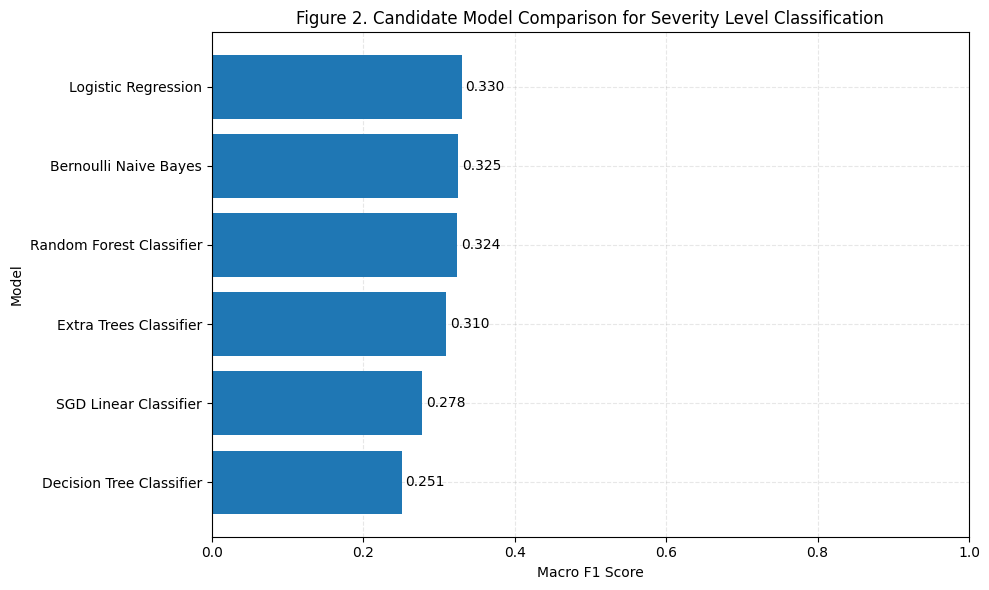

Saved figure: /kaggle/working/severity_classification_outputs/rq2_model_comparison/figure_rq2_candidate_model_comparison.pdf
RQ2 answer: Best candidate model by Macro F1 = Logistic Regression


In [3]:
rq2_dir = OUTPUT_ROOT / "rq2_model_comparison"
rq2_dir.mkdir(parents=True, exist_ok=True)

results, predictions = [], {}

for name, model in get_candidate_models().items():
    print(f"Training {name}...")
    metrics, pred, _ = fit_evaluate_model(name, model, X_train, X_test, y_train, y_test, preprocessor)
    results.append(metrics)
    predictions[name] = pred

rq2_table = pd.DataFrame(results)[["Model", "Accuracy", "Balanced Accuracy", "Precision Macro", "Recall Macro", "F1 Macro", "F1 Weighted", "Training Time Seconds"]].sort_values("F1 Macro", ascending=False)
rq2_table["Rank"] = range(1, len(rq2_table) + 1)
display(rq2_table)
save_table(rq2_table, "table_rq2_candidate_model_comparison.csv", rq2_dir)

fig, ax = plt.subplots(figsize=(10, 6))
ordered = rq2_table.sort_values("F1 Macro", ascending=True)
ax.barh(ordered["Model"], ordered["F1 Macro"])
ax.set_title("Figure 2. Candidate Model Comparison for Severity Level Classification")
ax.set_xlabel("Macro F1 Score")
ax.set_ylabel("Model")
ax.set_xlim(0, 1)
style_axes(ax)
for i, (_, row) in enumerate(ordered.iterrows()):
    ax.text(row["F1 Macro"] + 0.005, i, f"{row['F1 Macro']:.3f}", va="center")
fig.tight_layout()
save_figure(fig, "figure_rq2_candidate_model_comparison.pdf", rq2_dir)

best_rq2_model = rq2_table.iloc[0]["Model"]
print("RQ2 answer: Best candidate model by Macro F1 =", best_rq2_model)

## RQ3: Effect of preprocessing

Running: Basic encoded data
Running: Missing-value imputation
Running: Encoding + scaling
Running: Missing indicators added
Running: Full preprocessing pipeline


,Preprocessing Strategy,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted,Training Time Seconds
0,Basic encoded data,0.339750,0.340870,0.340417,0.340870,0.325553,0.325055,1.314799
1,Missing-value imputation,0.334500,0.332512,0.334097,0.332512,0.250816,0.251836,0.947321
2,Encoding + scaling,0.334500,0.332512,0.334097,0.332512,0.250816,0.251836,0.926739
3,Missing indicators added,0.334375,0.332385,0.333857,0.332385,0.250588,0.251610,0.948042
4,Full preprocessing pipeline,0.334375,0.332385,0.333857,0.332385,0.250588,0.251610,0.939569


Saved table: /kaggle/working/severity_classification_outputs/rq3_preprocessing_effects/table_rq3_preprocessing_effects.csv


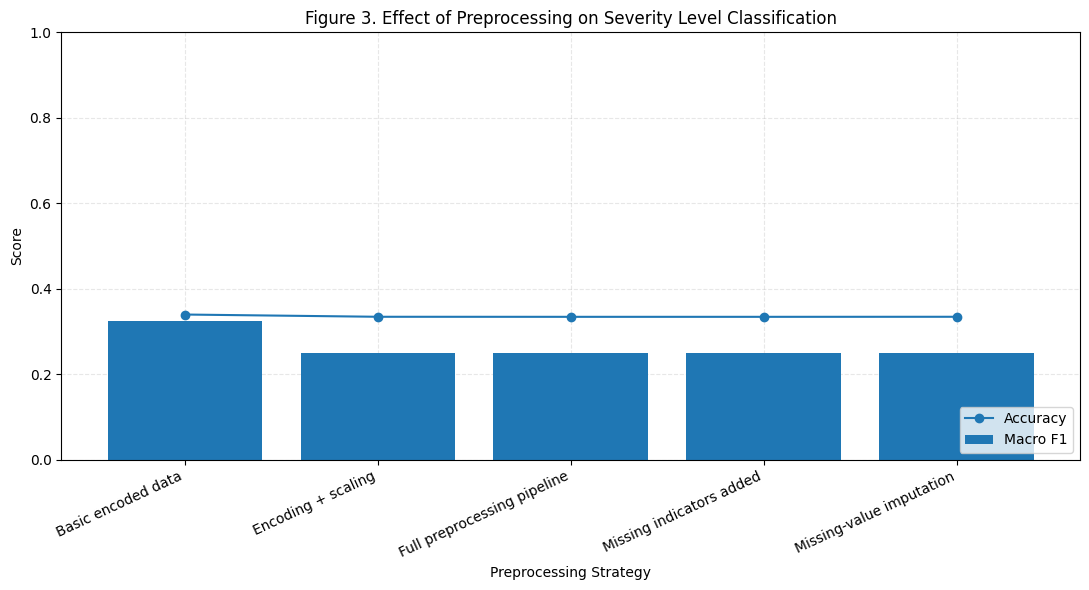

Saved figure: /kaggle/working/severity_classification_outputs/rq3_preprocessing_effects/figure_rq3_preprocessing_effects.pdf
RQ3 answer: Best preprocessing strategy = Basic encoded data


In [4]:
rq3_dir = OUTPUT_ROOT / "rq3_preprocessing_effects"
rq3_dir.mkdir(parents=True, exist_ok=True)

selected_model = DecisionTreeClassifier(max_depth=14, min_samples_leaf=5, class_weight="balanced", random_state=RANDOM_STATE)

configs = [
    {"Strategy": "Basic encoded data", "missing": False, "ip": False, "scale": False},
    {"Strategy": "Missing-value imputation", "missing": False, "ip": True, "scale": False},
    {"Strategy": "Encoding + scaling", "missing": False, "ip": True, "scale": True},
    {"Strategy": "Missing indicators added", "missing": True, "ip": True, "scale": True},
    {"Strategy": "Full preprocessing pipeline", "missing": True, "ip": True, "scale": True}
]

results = []
for cfg in configs:
    print("Running:", cfg["Strategy"])
    X_cfg, y_cfg = prepare_classification_features(df, create_missing_indicators=cfg["missing"], use_timestamp_features=True, use_ip_prefix_features=cfg["ip"], drop_high_cardinality_text=True)
    Xtr, Xte, ytr, yte = split_data(X_cfg, y_cfg, test_size=0.20)
    pre_cfg, _, _ = build_preprocessor(X_cfg, scale_numeric=cfg["scale"])
    metrics, _, _ = fit_evaluate_model(cfg["Strategy"], selected_model, Xtr, Xte, ytr, yte, pre_cfg)
    metrics["Preprocessing Strategy"] = cfg["Strategy"]
    results.append(metrics)

rq3_table = pd.DataFrame(results)[["Preprocessing Strategy", "Accuracy", "Balanced Accuracy", "Precision Macro", "Recall Macro", "F1 Macro", "F1 Weighted", "Training Time Seconds"]].sort_values("F1 Macro", ascending=False)
display(rq3_table)
save_table(rq3_table, "table_rq3_preprocessing_effects.csv", rq3_dir)

fig, ax = plt.subplots(figsize=(11, 6))
plot_df = rq3_table.sort_values("Preprocessing Strategy")
x = np.arange(len(plot_df))
ax.bar(x, plot_df["F1 Macro"], label="Macro F1")
ax.plot(x, plot_df["Accuracy"], marker="o", label="Accuracy")
ax.set_title("Figure 3. Effect of Preprocessing on Severity Level Classification")
ax.set_ylabel("Score")
ax.set_xlabel("Preprocessing Strategy")
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Preprocessing Strategy"], rotation=25, ha="right")
style_axes(ax)
ax.legend(loc="lower right")
fig.tight_layout()
save_figure(fig, "figure_rq3_preprocessing_effects.pdf", rq3_dir)

print("RQ3 answer: Best preprocessing strategy =", rq3_table.iloc[0]["Preprocessing Strategy"])

## RQ4: Feature importance and interpretability

,Rank,Feature,Importance,Interpretation
18,1,source_ip_prefix,0.188807,Associated with model prediction; not causal e...
17,2,proxy_ip_prefix,0.182327,Associated with model prediction; not causal e...
14,3,destination_ip_prefix,0.160078,Associated with model prediction; not causal e...
8,4,Packet Length,0.049153,Associated with model prediction; not causal e...
11,5,Source Port,0.044002,Associated with model prediction; not causal e...
13,6,dayofweek,0.041254,Associated with model prediction; not causal e...
2,7,Destination Port,0.038954,Associated with model prediction; not causal e...
10,8,Protocol,0.032708,Associated with model prediction; not causal e...
0,9,Alerts/Warnings,0.032700,Associated with model prediction; not causal e...
12,10,Traffic Type,0.030123,Associated with model prediction; not causal e...


Saved table: /kaggle/working/severity_classification_outputs/rq4_feature_importance/table_rq4_feature_importance.csv


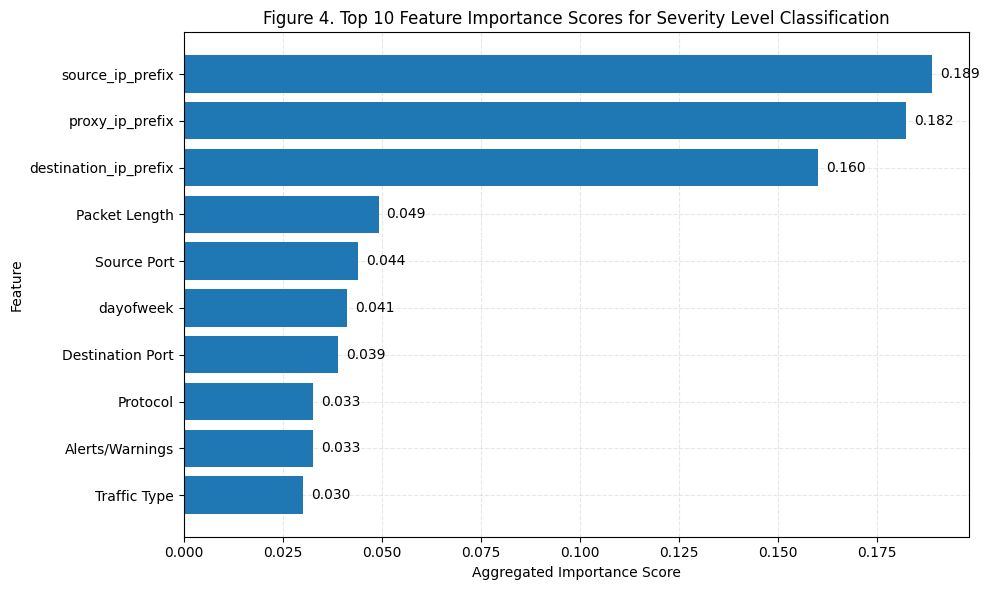

Saved figure: /kaggle/working/severity_classification_outputs/rq4_feature_importance/figure_rq4_feature_importance.pdf
RQ4 answer: Most important feature = source_ip_prefix


In [5]:
rq4_dir = OUTPUT_ROOT / "rq4_feature_importance"
rq4_dir.mkdir(parents=True, exist_ok=True)

feature_model = RandomForestClassifier(n_estimators=20, max_depth=10, min_samples_leaf=5, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1)
feature_pipe = Pipeline([("preprocessor", preprocessor), ("model", feature_model)])
feature_pipe.fit(X_train, y_train)

feature_names = feature_pipe.named_steps["preprocessor"].get_feature_names_out()
importances = feature_pipe.named_steps["model"].feature_importances_

raw_importance = pd.DataFrame({"Encoded Feature": feature_names, "Importance": importances})

def map_original_feature(encoded_name):
    name = encoded_name.replace("num__", "").replace("cat__", "")
    for col in sorted(categorical_features, key=len, reverse=True):
        if name == col or name.startswith(col + "_"):
            return col
    for col in numeric_features:
        if name == col:
            return col
    return name

raw_importance["Feature"] = raw_importance["Encoded Feature"].apply(map_original_feature)

rq4_table = raw_importance.groupby("Feature", as_index=False)["Importance"].sum().sort_values("Importance", ascending=False).head(15)
rq4_table["Rank"] = range(1, len(rq4_table) + 1)
rq4_table["Interpretation"] = "Associated with model prediction; not causal evidence"
rq4_table = rq4_table[["Rank", "Feature", "Importance", "Interpretation"]]
display(rq4_table)
save_table(rq4_table, "table_rq4_feature_importance.csv", rq4_dir)

fig, ax = plt.subplots(figsize=(10, 6))
top10 = rq4_table.head(10).sort_values("Importance", ascending=True)
ax.barh(top10["Feature"], top10["Importance"])
ax.set_title("Figure 4. Top 10 Feature Importance Scores for Severity Level Classification")
ax.set_xlabel("Aggregated Importance Score")
ax.set_ylabel("Feature")
style_axes(ax)
for i, (_, row) in enumerate(top10.iterrows()):
    ax.text(row["Importance"] + 0.002, i, f"{row['Importance']:.3f}", va="center")
fig.tight_layout()
save_figure(fig, "figure_rq4_feature_importance.pdf", rq4_dir)

print("RQ4 answer: Most important feature =", rq4_table.iloc[0]["Feature"])

## RQ5: Metric sensitivity

,Model,Rank by Accuracy,Rank by Precision Macro,Rank by Recall Macro,Rank by F1 Macro,Average Rank,Overall Rank
3,Extra Trees Classifier,2.0,3.0,1.0,4.0,2.50,1.0
1,Decision Tree Classifier,1.0,2.0,2.0,6.0,2.75,2.0
4,SGD Linear Classifier,3.0,1.0,3.0,5.0,3.00,3.0
0,Logistic Regression,4.0,4.0,4.0,1.0,3.25,4.0
2,Random Forest Classifier,5.0,5.0,5.0,3.0,4.50,5.0
5,Bernoulli Naive Bayes,6.0,6.0,6.0,2.0,5.00,6.0


Saved table: /kaggle/working/severity_classification_outputs/rq5_metric_sensitivity/table_rq5_metric_sensitivity.csv


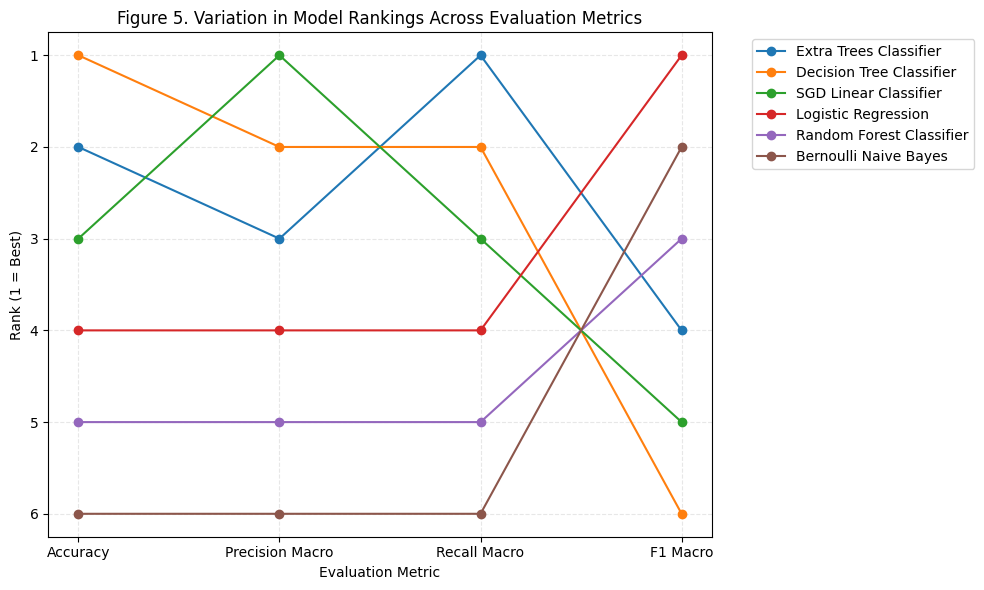

Saved figure: /kaggle/working/severity_classification_outputs/rq5_metric_sensitivity/figure_rq5_metric_sensitivity.pdf
RQ5 answer: Overall best-ranked model = Extra Trees Classifier


In [6]:
rq5_dir = OUTPUT_ROOT / "rq5_metric_sensitivity"
rq5_dir.mkdir(parents=True, exist_ok=True)

try:
    rq2_table
except NameError:
    results = []
    for name, model in get_candidate_models().items():
        print(f"Training {name}...")
        metrics, _, _ = fit_evaluate_model(name, model, X_train, X_test, y_train, y_test, preprocessor)
        results.append(metrics)
    rq2_table = pd.DataFrame(results)

metric_df = rq2_table.copy()
metric_df["Rank by Accuracy"] = metric_df["Accuracy"].rank(ascending=False, method="min")
metric_df["Rank by Precision Macro"] = metric_df["Precision Macro"].rank(ascending=False, method="min")
metric_df["Rank by Recall Macro"] = metric_df["Recall Macro"].rank(ascending=False, method="min")
metric_df["Rank by F1 Macro"] = metric_df["F1 Macro"].rank(ascending=False, method="min")
rank_cols = ["Rank by Accuracy", "Rank by Precision Macro", "Rank by Recall Macro", "Rank by F1 Macro"]
metric_df["Average Rank"] = metric_df[rank_cols].mean(axis=1)
metric_df["Overall Rank"] = metric_df["Average Rank"].rank(ascending=True, method="min")

rq5_table = metric_df[["Model"] + rank_cols + ["Average Rank", "Overall Rank"]].sort_values("Overall Rank")
display(rq5_table)
save_table(rq5_table, "table_rq5_metric_sensitivity.csv", rq5_dir)

fig, ax = plt.subplots(figsize=(10, 6))
criteria = ["Accuracy", "Precision Macro", "Recall Macro", "F1 Macro"]
rank_map = {"Accuracy": "Rank by Accuracy", "Precision Macro": "Rank by Precision Macro", "Recall Macro": "Rank by Recall Macro", "F1 Macro": "Rank by F1 Macro"}
for _, row in rq5_table.iterrows():
    ax.plot(criteria, [row[rank_map[c]] for c in criteria], marker="o", label=row["Model"])
ax.invert_yaxis()
ax.set_title("Figure 5. Variation in Model Rankings Across Evaluation Metrics")
ax.set_ylabel("Rank (1 = Best)")
ax.set_xlabel("Evaluation Metric")
ax.set_yticks(range(1, len(rq5_table) + 1))
style_axes(ax)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
fig.tight_layout()
save_figure(fig, "figure_rq5_metric_sensitivity.pdf", rq5_dir)

print("RQ5 answer: Overall best-ranked model =", rq5_table.iloc[0]["Model"])

## RQ6: Robustness and generalization

,Scenario,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted,CV Std. Dev.,Training Time Seconds
0,80/20 train-test split,0.334375,0.332385,0.333857,0.332385,0.250588,0.251610,NaN,0.909173
1,70/30 train-test split,0.336167,0.333941,0.338863,0.333941,0.224896,0.226095,NaN,0.799452
2,3-fold cross-validation,NaN,NaN,NaN,NaN,0.243322,NaN,0.035319,NaN
3,10% numeric noise added,0.334750,0.335571,0.336599,0.335571,0.327723,0.327357,NaN,1.576744
4,20% numeric missingness added,0.338875,0.336696,0.351621,0.336696,0.210122,0.211051,NaN,0.833298


Saved table: /kaggle/working/severity_classification_outputs/rq6_robustness_generalization/table_rq6_robustness_generalization.csv


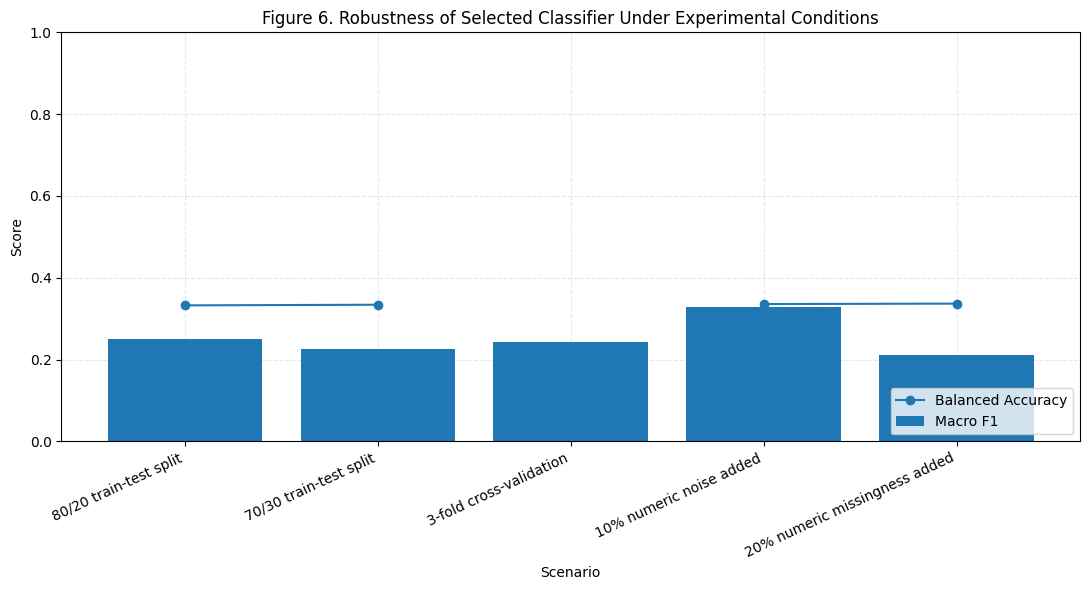

Saved figure: /kaggle/working/severity_classification_outputs/rq6_robustness_generalization/figure_rq6_robustness_generalization.pdf
RQ6 answer: Selected model tested = Decision Tree Classifier
3-fold CV Macro F1 mean = 0.2433 std = 0.0353


In [7]:
rq6_dir = OUTPUT_ROOT / "rq6_robustness_generalization"
rq6_dir.mkdir(parents=True, exist_ok=True)

selected_model_name = "Decision Tree Classifier"
selected_model = DecisionTreeClassifier(max_depth=14, min_samples_leaf=5, class_weight="balanced", random_state=RANDOM_STATE)

def evaluate_split(test_size, scenario):
    Xtr, Xte, ytr, yte = split_data(X, y, test_size=test_size)
    metrics, _, _ = fit_evaluate_model(selected_model_name, selected_model, Xtr, Xte, ytr, yte, preprocessor)
    metrics["Scenario"] = scenario
    return metrics

results = [
    evaluate_split(0.20, "80/20 train-test split"),
    evaluate_split(0.30, "70/30 train-test split")
]

cv_pipe = Pipeline([("preprocessor", preprocessor), ("model", selected_model)])
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(cv_pipe, X, y, cv=cv, scoring="f1_macro", n_jobs=1)

results.append({"Model": selected_model_name, "Accuracy": np.nan, "Balanced Accuracy": np.nan, "Precision Macro": np.nan, "Recall Macro": np.nan, "F1 Macro": cv_scores.mean(), "F1 Weighted": np.nan, "Training Time Seconds": np.nan, "Scenario": "3-fold cross-validation", "CV Std. Dev.": cv_scores.std()})

rng = np.random.default_rng(RANDOM_STATE)

X_noise = X.copy()
num_cols = X_noise.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
for col in num_cols:
    std = X_noise[col].std()
    if pd.notna(std) and std > 0:
        X_noise[col] = X_noise[col] + rng.normal(0, 0.10 * std, size=len(X_noise))

Xtr, Xte, ytr, yte = split_data(X_noise, y, test_size=0.20)
pre_noise, _, _ = build_preprocessor(X_noise, scale_numeric=True)
metrics, _, _ = fit_evaluate_model(selected_model_name, selected_model, Xtr, Xte, ytr, yte, pre_noise)
metrics["Scenario"] = "10% numeric noise added"
results.append(metrics)

X_missing = X.copy()
num_cols = X_missing.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
if num_cols:
    mask = rng.random(X_missing[num_cols].shape) < 0.20
    X_missing.loc[:, num_cols] = X_missing[num_cols].mask(mask)

Xtr, Xte, ytr, yte = split_data(X_missing, y, test_size=0.20)
pre_missing, _, _ = build_preprocessor(X_missing, scale_numeric=True)
metrics, _, _ = fit_evaluate_model(selected_model_name, selected_model, Xtr, Xte, ytr, yte, pre_missing)
metrics["Scenario"] = "20% numeric missingness added"
results.append(metrics)

rq6_table = pd.DataFrame(results)
if "CV Std. Dev." not in rq6_table.columns:
    rq6_table["CV Std. Dev."] = np.nan
rq6_table = rq6_table[["Scenario", "Accuracy", "Balanced Accuracy", "Precision Macro", "Recall Macro", "F1 Macro", "F1 Weighted", "CV Std. Dev.", "Training Time Seconds"]]
display(rq6_table)
save_table(rq6_table, "table_rq6_robustness_generalization.csv", rq6_dir)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(rq6_table))
ax.bar(x, rq6_table["F1 Macro"], label="Macro F1")
ax.plot(x, rq6_table["Balanced Accuracy"], marker="o", label="Balanced Accuracy")
ax.set_title("Figure 6. Robustness of Selected Classifier Under Experimental Conditions")
ax.set_ylabel("Score")
ax.set_xlabel("Scenario")
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(rq6_table["Scenario"], rotation=25, ha="right")
style_axes(ax)
ax.legend(loc="lower right")
fig.tight_layout()
save_figure(fig, "figure_rq6_robustness_generalization.pdf", rq6_dir)

print("RQ6 answer: Selected model tested =", selected_model_name)
print("3-fold CV Macro F1 mean =", round(cv_scores.mean(), 4), "std =", round(cv_scores.std(), 4))

## RQ7: Practical usefulness and final recommendation

,Model,Accuracy,Balanced Accuracy,F1 Macro,Predictive Performance Score,Interpretability Score,Robustness Score,Computational Cost Score,Deployment Suitability Score,Final Rank
0,Logistic Regression,0.330125,0.330088,0.330025,5.000000,5.0,5.000000,0.833333,4.375000,1
5,Bernoulli Naive Bayes,0.325625,0.325464,0.325155,4.166667,4.0,3.333333,5.000000,4.083333,2
2,Random Forest Classifier,0.327250,0.327086,0.323747,3.333333,3.8,4.166667,2.500000,3.491667,3
3,Extra Trees Classifier,0.333250,0.333598,0.309889,2.500000,3.4,2.500000,4.166667,2.975000,4
4,SGD Linear Classifier,0.331125,0.330838,0.277536,1.666667,3.6,1.666667,3.333333,2.400000,5
1,Decision Tree Classifier,0.334375,0.332385,0.250588,0.833333,4.2,0.833333,1.666667,1.800000,6


Saved table: /kaggle/working/severity_classification_outputs/rq7_final_recommendation/table_rq7_final_decision_matrix.csv


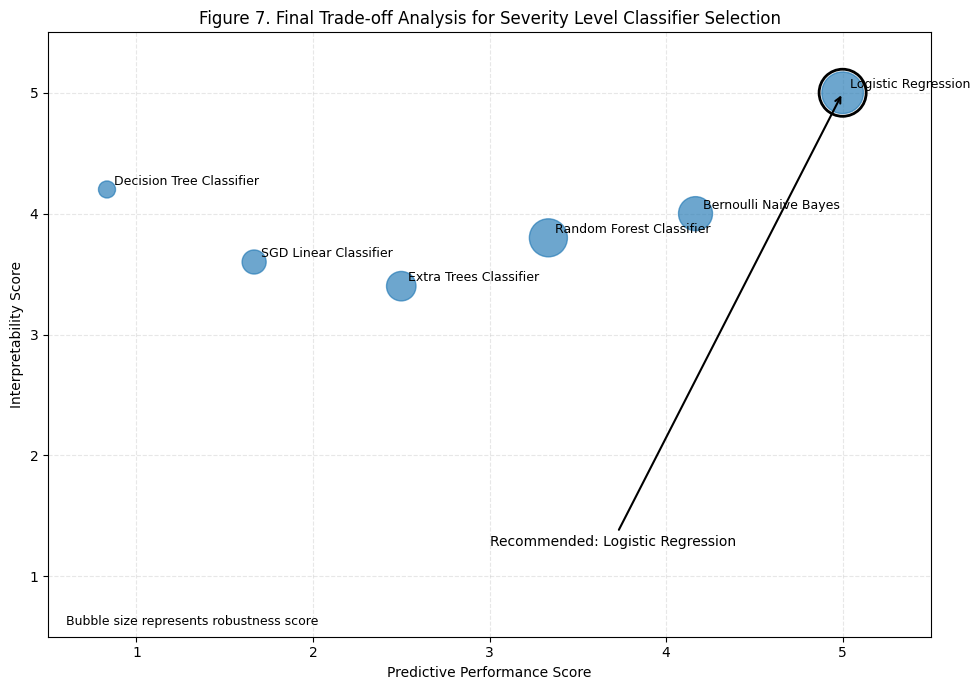

Saved figure: /kaggle/working/severity_classification_outputs/rq7_final_recommendation/figure_rq7_final_tradeoff.pdf
RQ7 answer: Recommended practical model = Logistic Regression


In [8]:
rq7_dir = OUTPUT_ROOT / "rq7_final_recommendation"
rq7_dir.mkdir(parents=True, exist_ok=True)

try:
    rq2_table
except NameError:
    results = []
    for name, model in get_candidate_models().items():
        print(f"Training {name}...")
        metrics, _, _ = fit_evaluate_model(name, model, X_train, X_test, y_train, y_test, preprocessor)
        results.append(metrics)
    rq2_table = pd.DataFrame(results)

decision_df = rq2_table.copy()
interpretability_scores = {
    "Logistic Regression": 5.0,
    "Decision Tree Classifier": 4.2,
    "Random Forest Classifier": 3.8,
    "Extra Trees Classifier": 3.4,
    "SGD Linear Classifier": 3.6,
    "Bernoulli Naive Bayes": 4.0
}
decision_df["Predictive Performance Score"] = decision_df["F1 Macro"].rank(ascending=True, method="average") / len(decision_df) * 5
decision_df["Interpretability Score"] = decision_df["Model"].map(interpretability_scores).fillna(3.0)
decision_df["Computational Cost Score"] = decision_df["Training Time Seconds"].rank(ascending=False, method="average") / len(decision_df) * 5
decision_df["Robustness Score"] = (0.5 * decision_df["Balanced Accuracy"] + 0.5 * decision_df["F1 Weighted"]).rank(ascending=True, method="average") / len(decision_df) * 5
decision_df["Deployment Suitability Score"] = 0.40 * decision_df["Predictive Performance Score"] + 0.25 * decision_df["Interpretability Score"] + 0.20 * decision_df["Robustness Score"] + 0.15 * decision_df["Computational Cost Score"]

rq7_table = decision_df[["Model", "Accuracy", "Balanced Accuracy", "F1 Macro", "Predictive Performance Score", "Interpretability Score", "Robustness Score", "Computational Cost Score", "Deployment Suitability Score"]].sort_values("Deployment Suitability Score", ascending=False)
rq7_table["Final Rank"] = range(1, len(rq7_table) + 1)
display(rq7_table)
save_table(rq7_table, "table_rq7_final_decision_matrix.csv", rq7_dir)

fig, ax = plt.subplots(figsize=(10, 7))
sizes = rq7_table["Robustness Score"] * 180
ax.scatter(rq7_table["Predictive Performance Score"], rq7_table["Interpretability Score"], s=sizes, alpha=0.65)
for _, row in rq7_table.iterrows():
    ax.text(row["Predictive Performance Score"] + 0.04, row["Interpretability Score"] + 0.04, row["Model"], fontsize=9)

recommended = rq7_table.iloc[0]
ax.scatter([recommended["Predictive Performance Score"]], [recommended["Interpretability Score"]], s=[recommended["Robustness Score"] * 230], facecolors="none", edgecolors="black", linewidths=2)
ax.annotate(f"Recommended: {recommended['Model']}", xy=(recommended["Predictive Performance Score"], recommended["Interpretability Score"]), xytext=(0.50, 0.15), textcoords="axes fraction", arrowprops=dict(arrowstyle="->", lw=1.5))

ax.set_title("Figure 7. Final Trade-off Analysis for Severity Level Classifier Selection")
ax.set_xlabel("Predictive Performance Score")
ax.set_ylabel("Interpretability Score")
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)
style_axes(ax)
ax.text(0.02, 0.02, "Bubble size represents robustness score", transform=ax.transAxes, fontsize=9)
fig.tight_layout()
save_figure(fig, "figure_rq7_final_tradeoff.pdf", rq7_dir)

print("RQ7 answer: Recommended practical model =", recommended["Model"])

## Output inventory

In [9]:
all_outputs = []
for path in sorted(OUTPUT_ROOT.rglob("*")):
    if path.is_file() and path.suffix.lower() in [".csv", ".pdf"]:
        all_outputs.append({"File": path.name, "Path": str(path), "Type": path.suffix.lower()})
inventory_df = pd.DataFrame(all_outputs)
display(inventory_df)
save_table(inventory_df, "output_inventory.csv", OUTPUT_ROOT)
print("All outputs were saved under:", OUTPUT_ROOT)

,File,Path,Type
0,figure_rq1_baseline_classification.pdf,/kaggle/working/severity_classification_output...,.pdf
1,table_rq1_baseline_classification.csv,/kaggle/working/severity_classification_output...,.csv
2,table_rq1_best_model_confusion_matrix.csv,/kaggle/working/severity_classification_output...,.csv
3,figure_rq2_candidate_model_comparison.pdf,/kaggle/working/severity_classification_output...,.pdf
4,table_rq2_candidate_model_comparison.csv,/kaggle/working/severity_classification_output...,.csv
5,figure_rq3_preprocessing_effects.pdf,/kaggle/working/severity_classification_output...,.pdf
6,table_rq3_preprocessing_effects.csv,/kaggle/working/severity_classification_output...,.csv
7,figure_rq4_feature_importance.pdf,/kaggle/working/severity_classification_output...,.pdf
8,table_rq4_feature_importance.csv,/kaggle/working/severity_classification_output...,.csv
9,figure_rq5_metric_sensitivity.pdf,/kaggle/working/severity_classification_output...,.pdf


Saved table: /kaggle/working/severity_classification_outputs/output_inventory.csv
All outputs were saved under: /kaggle/working/severity_classification_outputs
